# EDA & Clustering — Dataset 2: Behavioral & Lifestyle

## 1. Imports & config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
PALETTE = {0: '#378ADD', 1: '#EF9F27', 2: '#E24B4A'}

In [15]:
# Load the core clustering dataset
df = pd.read_csv('Dataset_2_Behavioral_Lifestyle/dataset2_behavioral_lifestyle_core.csv')
df.drop(columns=['attendance_engagement_score'], inplace=True, errors='ignore')
print(f"Shape: {df.shape}")
df.head()

Shape: (892, 35)


,behavior_student_id,source_dataset,age,gender_female_binary,academic_level_num,study_hours_daily,self_study_hours_daily,online_classes_hours_daily,social_media_hours_daily,gaming_hours_daily,sleep_hours,screen_time_hours_daily,exercise_minutes_daily,caffeine_intake_daily,part_time_job_binary,internet_quality_score,mental_health_score,focus_score,burnout_score,productivity_score,stress_score,assignment_punctuality_score,motivation_score,satisfaction_score,study_planning_score,extra_academic_work_binary,total_learning_hours_daily,distraction_hours_daily,sleep_balance_score,wellbeing_score,discipline_score,engagement_score,distraction_risk_score,behavioral_risk_score,observed_behavior_feature_count
0,B0001,Assessment (Responses) - Form Responses 1 (1).csv,18.0,1.0,2.0,0.857143,5.080404,0.099844,1.0,0.099002,5.0,11.378046,5.0,1.207996,0.0,3.0,6.022805,4.0,5.0,8.219670,10.0,4.0,2.014722,2.0,1.0,0.0,5.987469,1.099002,6.25,3.807982,3.50,2.909043,4.616933,5.384578,14
1,B0002,Assessment (Responses) - Form Responses 1 (1).csv,18.0,1.0,2.0,0.428571,2.898281,0.827013,4.0,1.084927,8.0,5.869530,35.0,2.030096,0.0,5.0,2.109202,2.0,5.0,4.218584,8.0,3.0,4.964530,2.0,2.0,1.0,3.740359,5.084927,9.25,3.538221,3.10,5.266827,5.770205,5.324378,13
2,B0003,Assessment (Responses) - Form Responses 1 (1).csv,18.0,1.0,1.0,0.857143,10.146661,3.030949,6.0,0.000000,8.0,2.996318,5.0,7.738430,0.0,3.0,4.813977,3.0,5.0,2.984258,10.0,3.0,5.099731,3.0,4.0,1.0,12.519278,6.000000,9.25,3.984892,3.75,7.131057,5.498773,4.396461,14
3,B0004,Assessment (Responses) - Form Responses 1 (1).csv,18.0,0.0,2.0,0.428571,3.009012,1.825843,2.0,0.000000,5.0,9.548379,35.0,0.868602,0.0,4.0,4.986637,4.0,5.0,4.205144,3.0,1.0,3.990628,3.0,1.0,0.0,4.350505,2.000000,6.25,5.195323,2.45,3.316105,4.682793,5.303075,14
4,B0005,Assessment (Responses) - Form Responses 1 (1).csv,22.0,1.0,2.0,0.000000,4.042456,2.048426,2.0,0.902897,5.0,8.833490,35.0,1.155148,0.0,4.0,3.248138,3.0,5.0,5.197950,8.0,4.0,1.952832,3.0,3.0,0.0,5.066669,2.902897,6.25,3.336848,3.85,3.195012,5.121670,5.440610,14


In [16]:
miss = df.isnull().sum()
print(miss[miss > 0].to_string() if miss.any() else '  No missing values ✓')


  No missing values ✓


##  Academic level & demographic breakdown

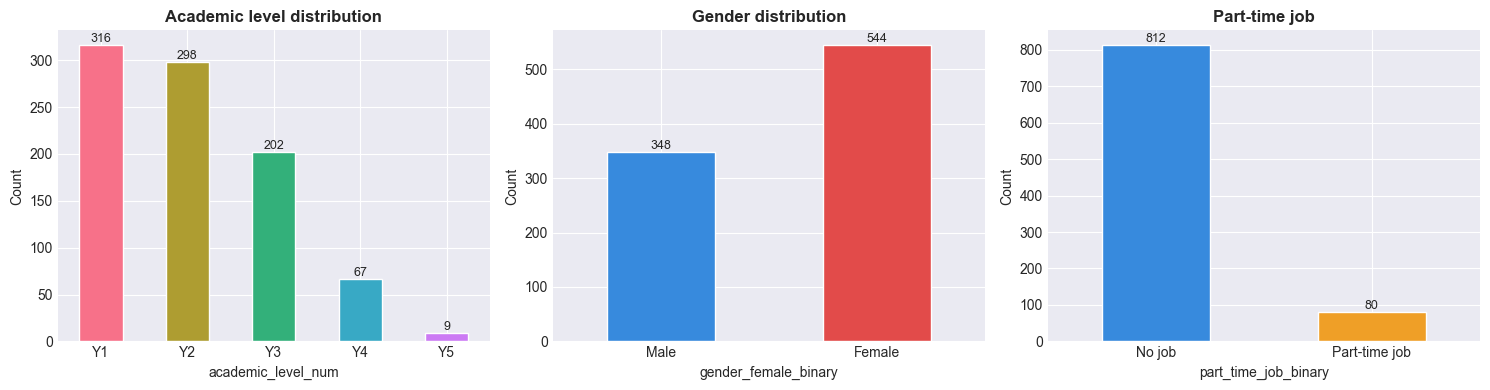


=== Key behavioral means by academic level ===
                    stress_score  motivation_score  wellbeing_score  study_hours_daily  behavioral_risk_score
academic_level_num                                                                                           
1.0                        3.669             3.383            5.352              6.653                  4.395
2.0                        3.875             3.410            5.319              5.589                  4.460
3.0                        5.639             3.295            4.993              5.373                  4.549
4.0                        6.286             3.219            4.921              5.622                  4.486
5.0                        6.861             2.700            4.357              6.611                  4.444


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Academic level
lvl = df['academic_level_num'].value_counts().sort_index()
lvl.index = lvl.index.map({1:'Y1',2:'Y2',3:'Y3',4:'Y4',5:'Y5'})
lvl.plot.bar(ax=axes[0], color=sns.color_palette('husl', len(lvl)), edgecolor='white', rot=0)
axes[0].set_title('Academic level distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Gender
gnd = df['gender_female_binary'].value_counts().sort_index()
gnd.index = gnd.index.map({0:'Male', 1:'Female'})
gnd.plot.bar(ax=axes[1], color=['#378ADD','#E24B4A'], edgecolor='white', rot=0)
axes[1].set_title('Gender distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Part-time job
job = df['part_time_job_binary'].value_counts().sort_index()
job.index = job.index.map({0:'No job', 1:'Part-time job'})
job.plot.bar(ax=axes[2], color=['#378ADD','#EF9F27'], edgecolor='white', rot=0)
axes[2].set_title('Part-time job', fontweight='bold')
axes[2].set_ylabel('Count')
for p in axes[2].patches:
    axes[2].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('\n=== Key behavioral means by academic level ===')
key_cols = ['stress_score', 'motivation_score', 'wellbeing_score',
            'study_hours_daily', 'behavioral_risk_score']
print(df.groupby('academic_level_num')[key_cols].mean().round(3).to_string())


##  Descriptive statistics

In [18]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
stats = df[num_cols].describe().T
stats['skewness'] = df[num_cols].skew().round(3)
stats['kurtosis'] = df[num_cols].kurt().round(3)
stats.round(3)


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,892.0,18.561,1.990,16.000,16.111,18.218,20.000,27.000,0.235,-0.513
gender_female_binary,892.0,0.610,0.488,0.000,0.000,1.000,1.000,1.000,-0.451,-1.800
academic_level_num,892.0,2.053,0.985,1.000,1.000,2.000,3.000,5.000,0.622,-0.378
study_hours_daily,892.0,5.930,4.627,0.000,2.571,4.857,8.000,14.000,0.820,-0.706
self_study_hours_daily,892.0,3.143,1.942,0.000,1.972,2.983,4.039,12.175,1.131,2.596
online_classes_hours_daily,892.0,1.236,1.558,0.000,0.049,1.000,1.969,12.000,3.285,17.366
social_media_hours_daily,892.0,3.379,2.108,0.000,1.909,3.000,4.786,10.270,1.022,1.045
gaming_hours_daily,892.0,0.572,1.092,0.000,0.000,0.025,0.980,9.109,3.199,15.108
sleep_hours,892.0,6.105,1.341,2.000,5.000,6.000,7.000,10.000,0.517,-0.721
screen_time_hours_daily,892.0,8.317,3.075,0.499,6.000,8.047,10.000,17.602,0.400,0.097


##  Distributions — behavioral features

Split into three thematic groups for readability.  
Mean (navy dashed) and median (orange dotted) are overlaid on each plot.


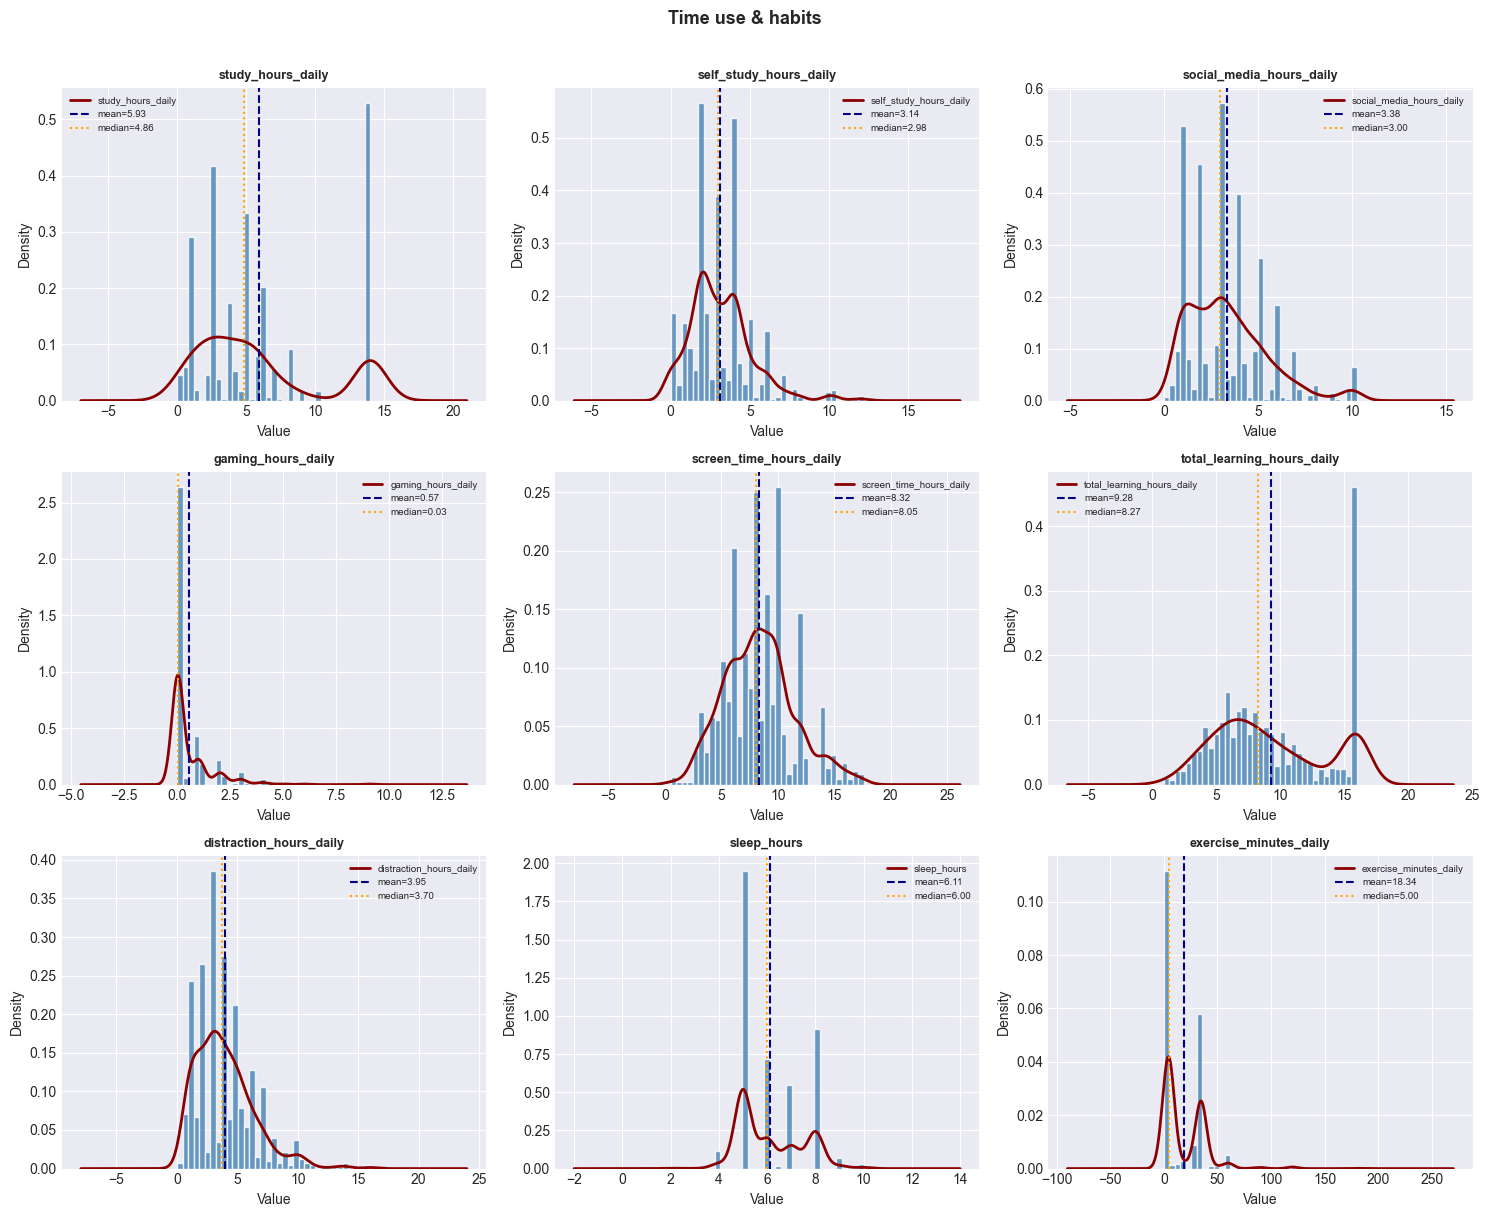

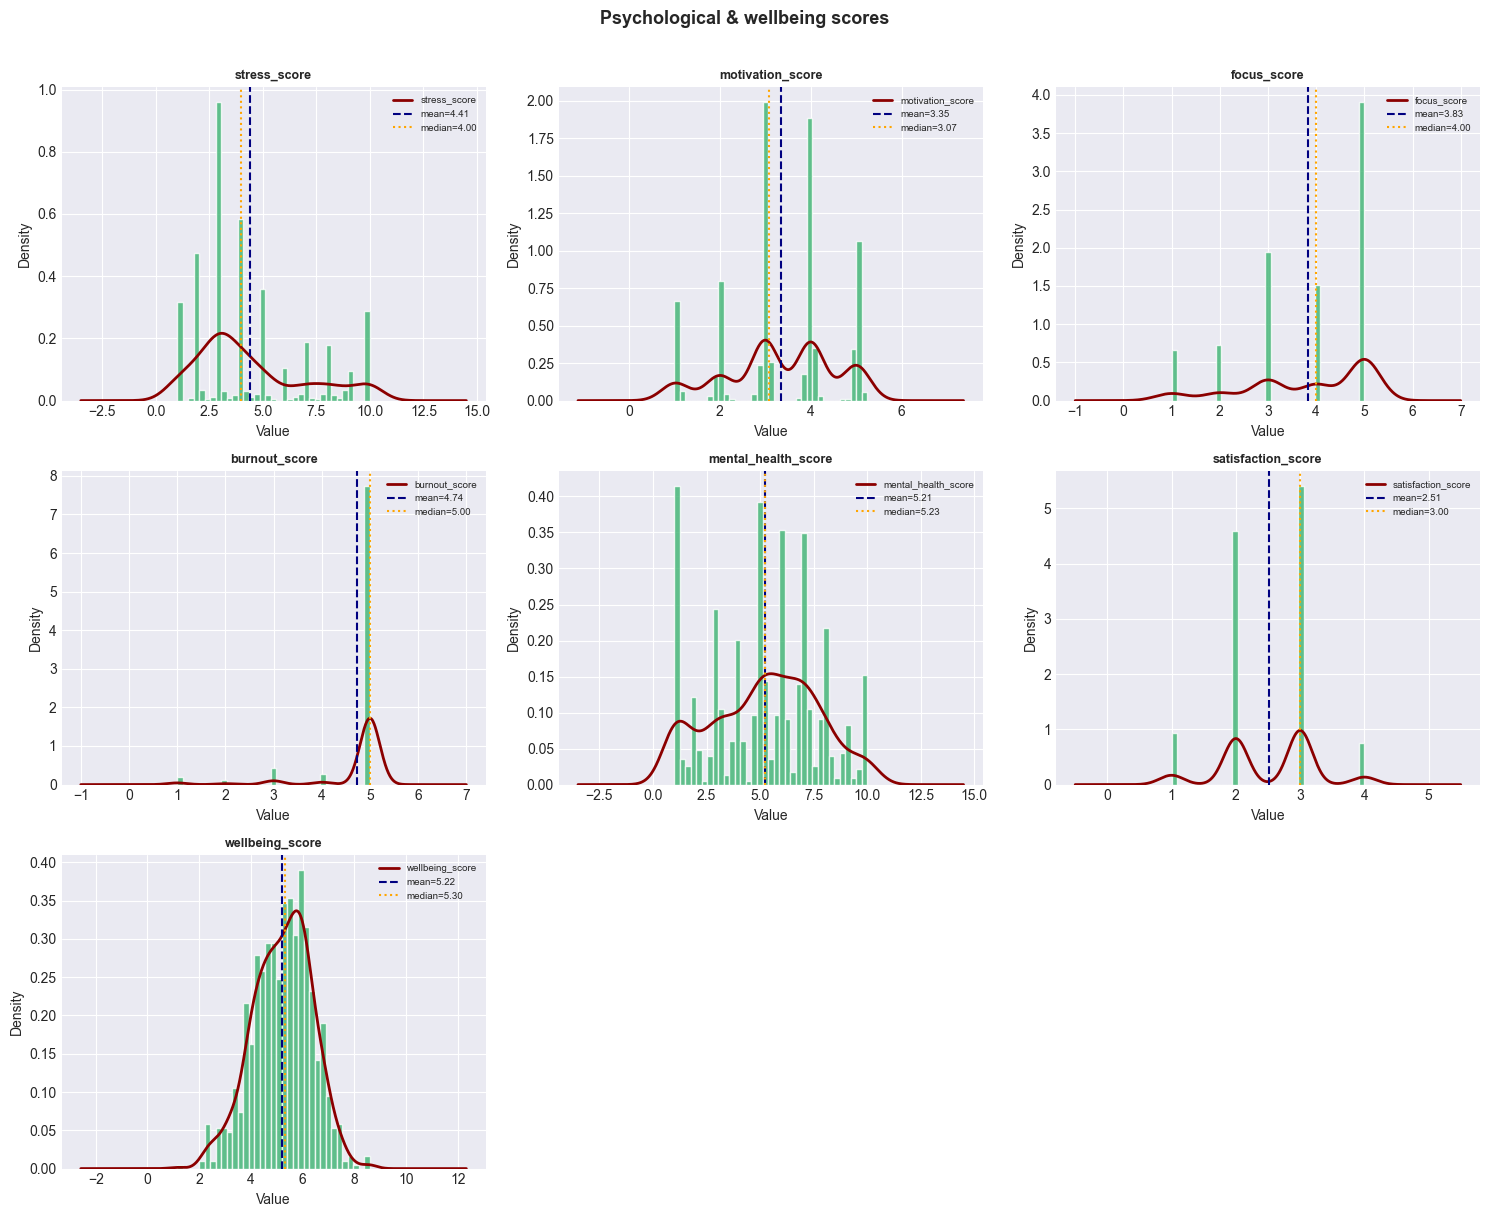

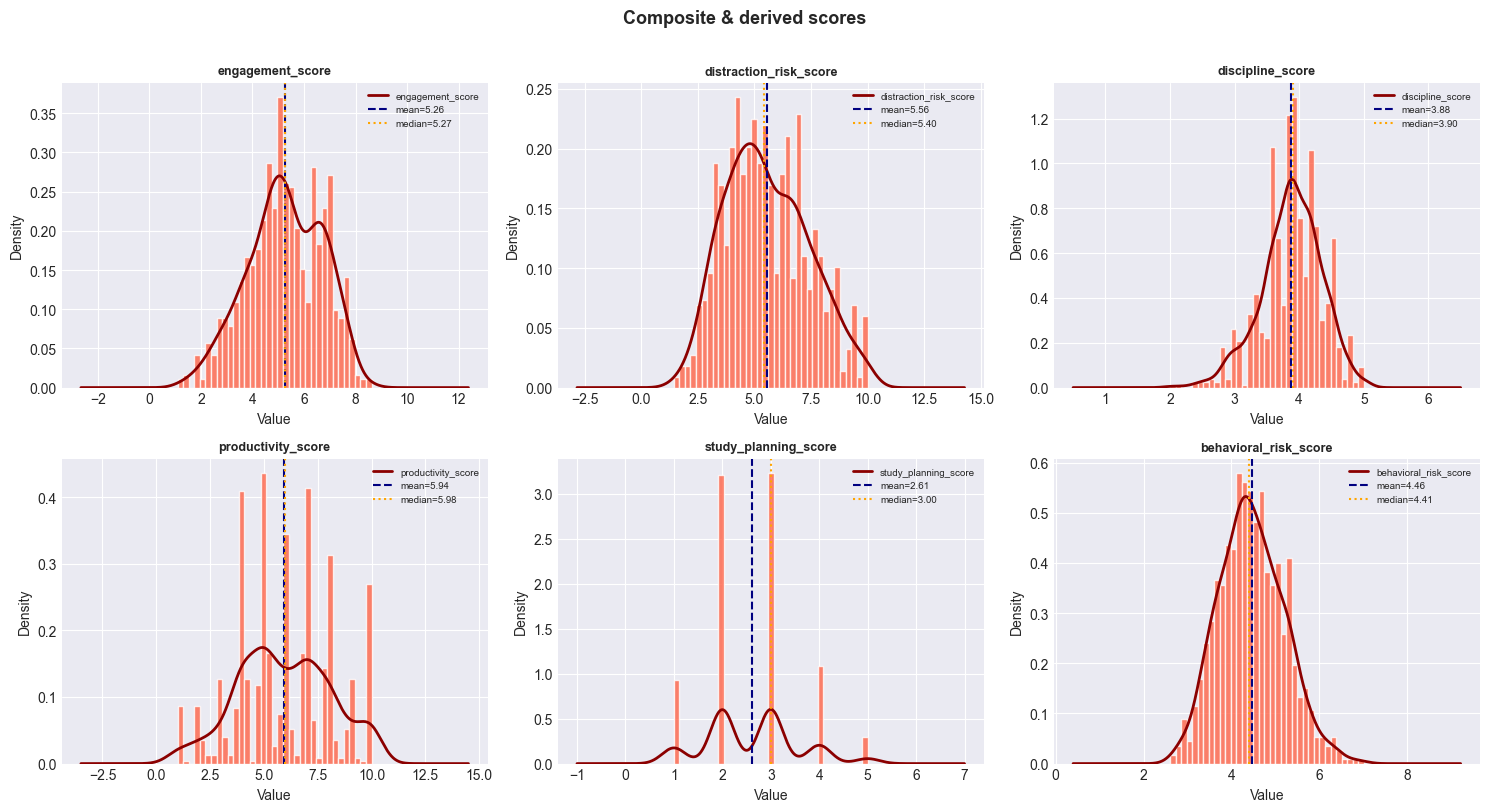

In [19]:

def dist_grid(df, cols, title, color='steelblue', ncols=3):
    cols = [c for c in cols if c in df.columns]
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(cols):
        data = df[col].dropna()
        axes[i].hist(data, bins=35, color=color, edgecolor='white', alpha=0.8, density=True)
        try:
            data.plot.kde(ax=axes[i], color='darkred', linewidth=2)
        except Exception:
            pass
        axes[i].axvline(data.mean(),   color='navy',   ls='--', lw=1.5, label=f'mean={data.mean():.2f}')
        axes[i].axvline(data.median(), color='orange', ls=':',  lw=1.5, label=f'median={data.median():.2f}')
        axes[i].set_title(col, fontsize=9, fontweight='bold')
        axes[i].legend(fontsize=7)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Density')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# Group 1 — Time use
time_cols = ['study_hours_daily', 'self_study_hours_daily', 'social_media_hours_daily',
             'gaming_hours_daily', 'screen_time_hours_daily', 'total_learning_hours_daily',
             'distraction_hours_daily', 'sleep_hours', 'exercise_minutes_daily']
dist_grid(df, time_cols, 'Time use & habits', color='steelblue')

# Group 2 — Psychological scores
psych_cols = ['stress_score', 'motivation_score', 'focus_score', 'burnout_score',
              'mental_health_score', 'satisfaction_score', 'wellbeing_score']
dist_grid(df, psych_cols, 'Psychological & wellbeing scores', color='mediumseagreen')

# Group 3 — Composite/derived scores
comp_cols = ['engagement_score', 'distraction_risk_score', 'discipline_score',
             'productivity_score', 'study_planning_score', 'behavioral_risk_score']
dist_grid(df, comp_cols, 'Composite & derived scores', color='tomato')




### Time use & habits
`study_hours_daily` is bimodal (mean 5.9) — two distinct groups of light and heavy
studiers coexist in the population. `gaming_hours_daily` is extremely right-skewed
(median ≈ 0) — the vast majority of students do not game. `sleep_hours` clusters
tightly around 6 hours, slightly below the healthy threshold of 7–8.
`exercise_minutes_daily` is heavily right-skewed with most students reporting little
to no physical activity. `screen_time_hours_daily` averages 8.3 hours daily — notably
high and worth flagging as a distraction risk. Note: KDE curves bleeding into negative
values on all time-use plots are a boundary effect of the kernel estimator, not actual
negative data.

### Psychological & wellbeing scores
`burnout_score` is sharply left-skewed with median 5.0/5 — near-universal burnout
across the dataset, making it a poor discriminator and justifying its exclusion from
clustering features. `motivation_score` and `focus_score` are both bimodal, suggesting
two distinct student mindsets rather than a smooth continuum. `stress_score` is
right-skewed with a meaningful high-stress tail. `wellbeing_score` is the most normally
distributed of this group and the best suited for clustering. `satisfaction_score` and
`mental_health_score` are multimodal, reflecting genuine subgroup differences in the
population.

### Composite & derived scores
`engagement_score` and `behavioral_risk_score` are approximately normal and
well-calibrated — confirming they are appropriate clustering features.
`distraction_risk_score` is right-skewed, meaning high distraction affects a minority
but is a strong signal when present. `study_planning_score` shows clear spikes at
integer values (1, 2, 3, 5) — it is an ordinal survey item, not a continuous score,
and should be treated as categorical in any downstream classifier. `productivity_score`
is bimodal, pointing to two distinct productivity profiles in the population.
"""))

##  Outlier analysis (IQR method)

=== Outlier summary ===
                             Q1     Q3    IQR  mild_outliers  mild_pct  extreme_outliers  extreme_pct
feature                                                                                              
burnout_score             5.000  5.000  0.000            104     11.66               104        11.66
motivation_score          2.939  4.000  1.061             79      8.86                 0         0.00
social_media_hours_daily  1.909  4.786  2.876             24      2.69                 0         0.00
wellbeing_score           4.420  6.026  1.606              4      0.45                 0         0.00
behavioral_risk_score     3.946  4.955  1.009              4      0.45                 0         0.00
study_hours_daily         2.571  8.000  5.429              0      0.00                 0         0.00
sleep_hours               5.000  7.000  2.000              0      0.00                 0         0.00
stress_score              3.000  6.000  3.000             

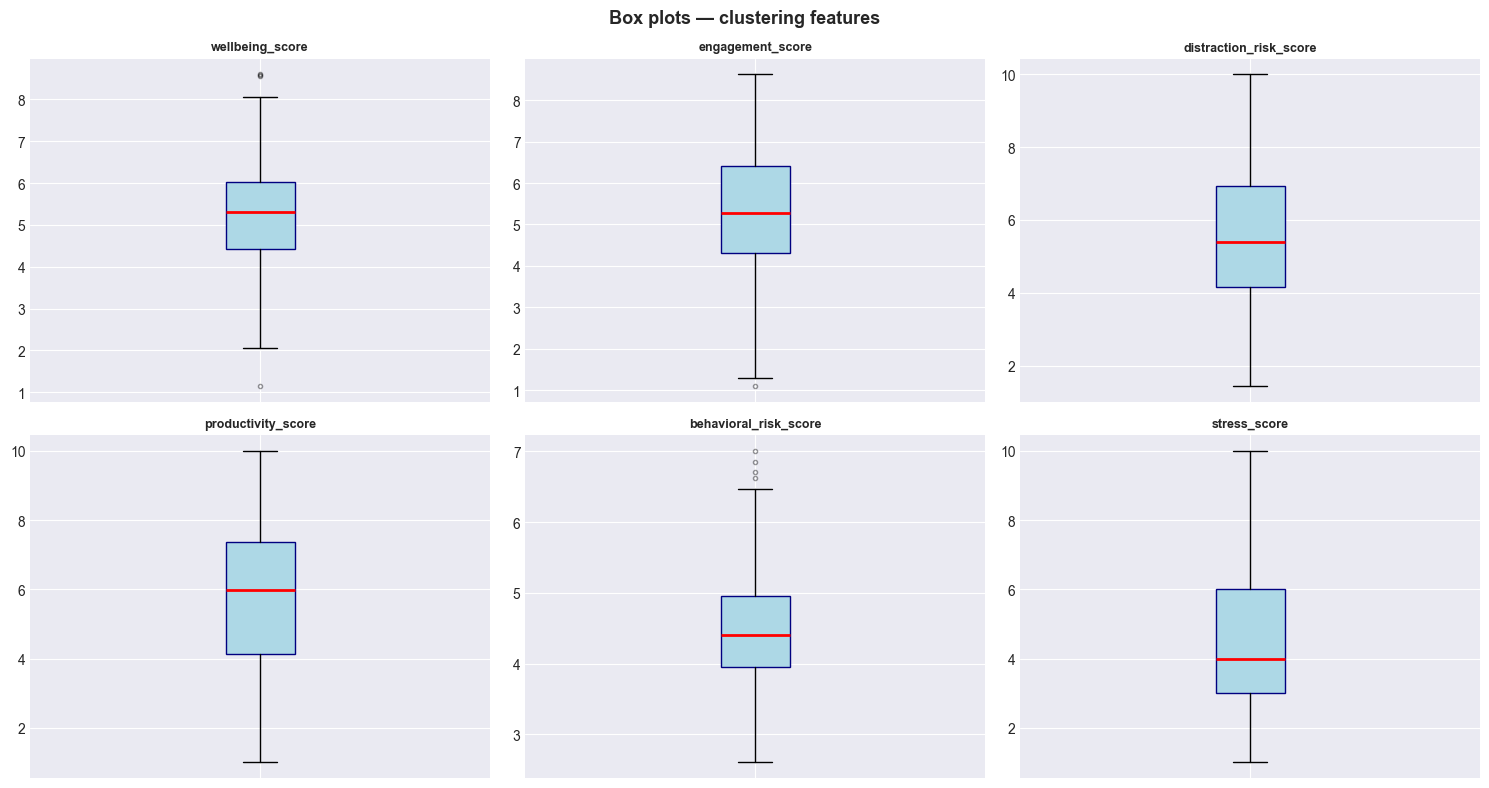

In [20]:
def iqr_outliers(df, cols):
    rows = []
    for c in [x for x in cols if x in df.columns]:
        s = df[c].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        mild  = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
        ext   = ((s < q1 - 3.0*iqr) | (s > q3 + 3.0*iqr)).sum()
        rows.append({
            'feature': c, 'Q1': round(q1, 3), 'Q3': round(q3, 3), 'IQR': round(iqr, 3),
            'mild_outliers': mild, 'mild_pct': round(mild/len(s)*100, 2),
            'extreme_outliers': ext, 'extreme_pct': round(ext/len(s)*100, 2)
        })
    return pd.DataFrame(rows).set_index('feature')

CLUSTER_COLS = [
    'wellbeing_score', 'engagement_score', 'distraction_risk_score',
    'productivity_score', 'behavioral_risk_score'
]

check_cols = ['study_hours_daily', 'sleep_hours', 'social_media_hours_daily',
              'stress_score', 'motivation_score', 'wellbeing_score',
              'distraction_risk_score', 'behavioral_risk_score', 'burnout_score']
outlier_report = iqr_outliers(df, check_cols)
print('=== Outlier summary ===')
print(outlier_report.sort_values('mild_pct', ascending=False).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(CLUSTER_COLS + ['stress_score']):
    if col in df.columns:
        axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', color='navy'),
                        medianprops=dict(color='red', linewidth=2),
                        flierprops=dict(marker='o', markersize=3, alpha=0.4))
        axes[i].set_title(col, fontsize=9, fontweight='bold')
        axes[i].set_xticklabels([])
fig.suptitle('Box plots — clustering features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Behavioral risk score deep-dive

`behavioral_risk_score` is on a 0–10 scale (unlike Dataset 1 which used 0–1).  
At-risk threshold is set at mean + 0.5 std ≈ 4.83, capturing the top ~30% of students.


At-risk students (score >= 4.83): 273 / 892 (30.6%)


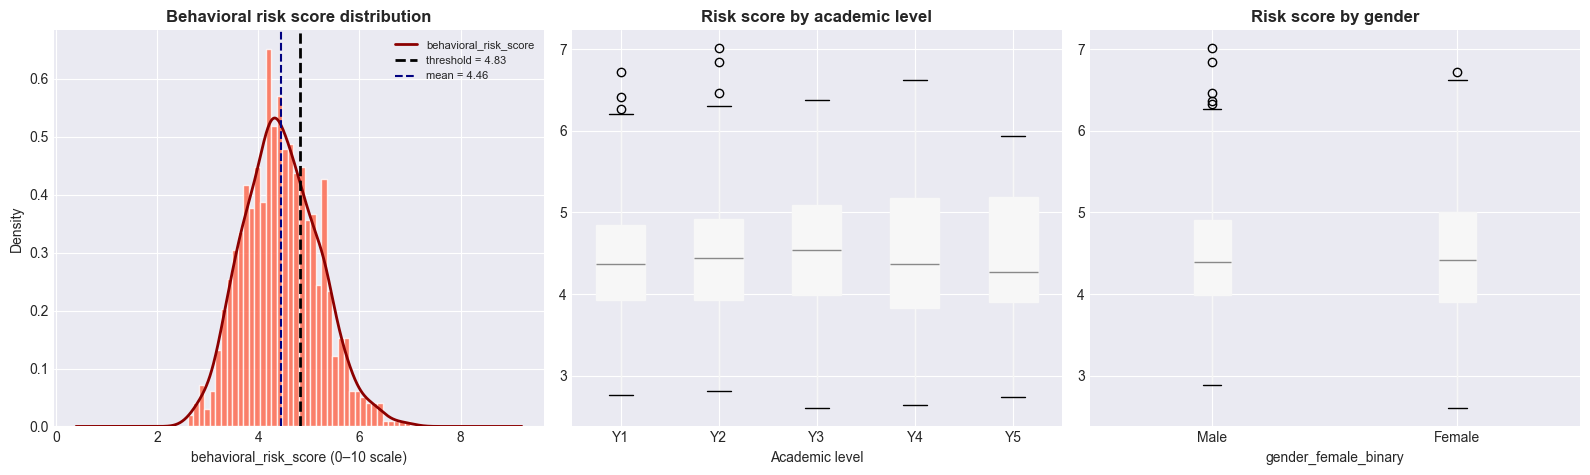


=== At-risk rate per academic level ===
                    at_risk_n  total  at_risk_rate
academic_level_num                                
1.0                        86    316         0.272
2.0                        87    298         0.292
3.0                        73    202         0.361
4.0                        23     67         0.343
5.0                         4      9         0.444


In [21]:
# At-risk threshold = mean + 0.5 std ≈ 4.83
RISK_THRESHOLD = 4.83
df['at_risk_label'] = (df['behavioral_risk_score'] >= RISK_THRESHOLD).astype(int)
at_risk_n   = df['at_risk_label'].sum()
at_risk_pct = at_risk_n / len(df) * 100
print(f'At-risk students (score >= {RISK_THRESHOLD}): {at_risk_n} / {len(df)} ({at_risk_pct:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution
risk = df['behavioral_risk_score'].dropna()
axes[0].hist(risk, bins=40, color='tomato', edgecolor='white', alpha=0.8, density=True)
risk.plot.kde(ax=axes[0], color='darkred', linewidth=2)
axes[0].axvline(RISK_THRESHOLD, color='black', ls='--', lw=2, label=f'threshold = {RISK_THRESHOLD}')
axes[0].axvline(risk.mean(), color='navy', ls='--', lw=1.5, label=f'mean = {risk.mean():.2f}')
axes[0].set_title('Behavioral risk score distribution', fontweight='bold')
axes[0].set_xlabel('behavioral_risk_score (0–10 scale)')
axes[0].legend(fontsize=8)

# By academic level
df.boxplot(column='behavioral_risk_score', by='academic_level_num', ax=axes[1], patch_artist=True)
axes[1].set_title('Risk score by academic level', fontweight='bold')
axes[1].set_xlabel('Academic level')
axes[1].set_xticklabels(['Y1','Y2','Y3','Y4','Y5'])
plt.sca(axes[1])

# By gender
df.boxplot(column='behavioral_risk_score', by='gender_female_binary', ax=axes[2], patch_artist=True)
axes[2].set_title('Risk score by gender', fontweight='bold')
axes[2].set_xticklabels(['Male', 'Female'])

fig.suptitle('')
plt.tight_layout()
plt.show()

print('\n=== At-risk rate per academic level ===')
print(df.groupby('academic_level_num')['at_risk_label']
        .agg(['sum','count','mean'])
        .rename(columns={'sum':'at_risk_n','count':'total','mean':'at_risk_rate'})
        .round(3).to_string())


##  Correlation analysis

=== Top 12 strongest correlations ===
                   feature_1                       feature_2      r
           study_hours_daily      total_learning_hours_daily  0.903
    social_media_hours_daily         distraction_hours_daily  0.893
                 sleep_hours             sleep_balance_score  0.889
     distraction_hours_daily          distraction_risk_score  0.844
         mental_health_score                 wellbeing_score  0.816
    social_media_hours_daily          distraction_risk_score  0.772
assignment_punctuality_score                discipline_score  0.747
      distraction_risk_score           behavioral_risk_score  0.667
                stress_score observed_behavior_feature_count  0.584
  total_learning_hours_daily                engagement_score  0.574
     distraction_hours_daily           behavioral_risk_score  0.560
            engagement_score           behavioral_risk_score -0.555


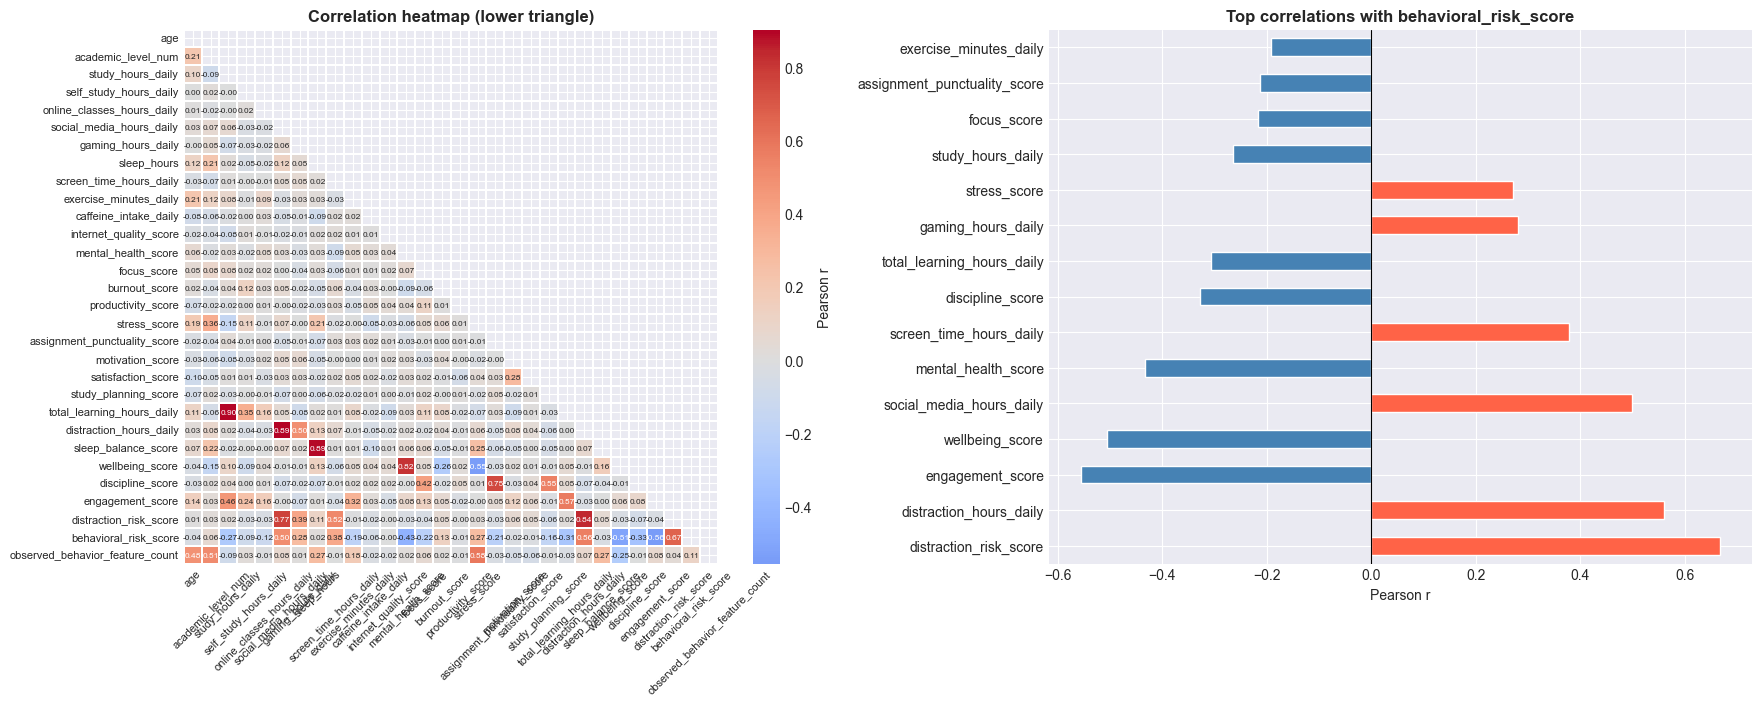

In [22]:
corr_cols = [c for c in df.select_dtypes(include=np.number).columns
             if c not in ['gender_female_binary','part_time_job_binary',
                           'extra_academic_work_binary','at_risk_label']]
corr = df[corr_cols].corr()

# Top pairs
pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        pairs.append({'feature_1': corr.columns[i], 'feature_2': corr.columns[j],
                      'r': round(corr.iloc[i,j], 3)})
top_pairs = (pd.DataFrame(pairs)
               .assign(abs_r=lambda d: d['r'].abs())
               .nlargest(12, 'abs_r')[['feature_1','feature_2','r']])
print('=== Top 12 strongest correlations ===')
print(top_pairs.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[0], linewidths=0.3,
            annot_kws={'size': 6}, cbar_kws={'label': 'Pearson r'})
axes[0].set_title('Correlation heatmap (lower triangle)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

risk_corr = corr['behavioral_risk_score'].drop('behavioral_risk_score').sort_values(key=abs, ascending=False).head(15)
colors = ['tomato' if v > 0 else 'steelblue' for v in risk_corr]
risk_corr.plot.barh(ax=axes[1], color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson r')
axes[1].set_title('Top correlations with behavioral_risk_score', fontweight='bold')

plt.tight_layout()
plt.show()


### Correlations
- `distraction_risk_score` is the strongest positive predictor of behavioral risk (r = 0.667), followed by `distraction_hours_daily` (r = 0.560).
- `engagement_score` (r = −0.555) and `wellbeing_score` (r = −0.505) are the strongest protective factors.
- Unlike Dataset 1, correlations here are moderate rather than near-perfect — behavioral features are genuinely multi-dimensional and less redundant.

##  Pairplot — separability check

Sample of 400 students coloured by at-risk label.  
Note: behavioral data is inherently less separable than academic grades —  
lower cluster contrast is expected and reflected in silhouette scores.


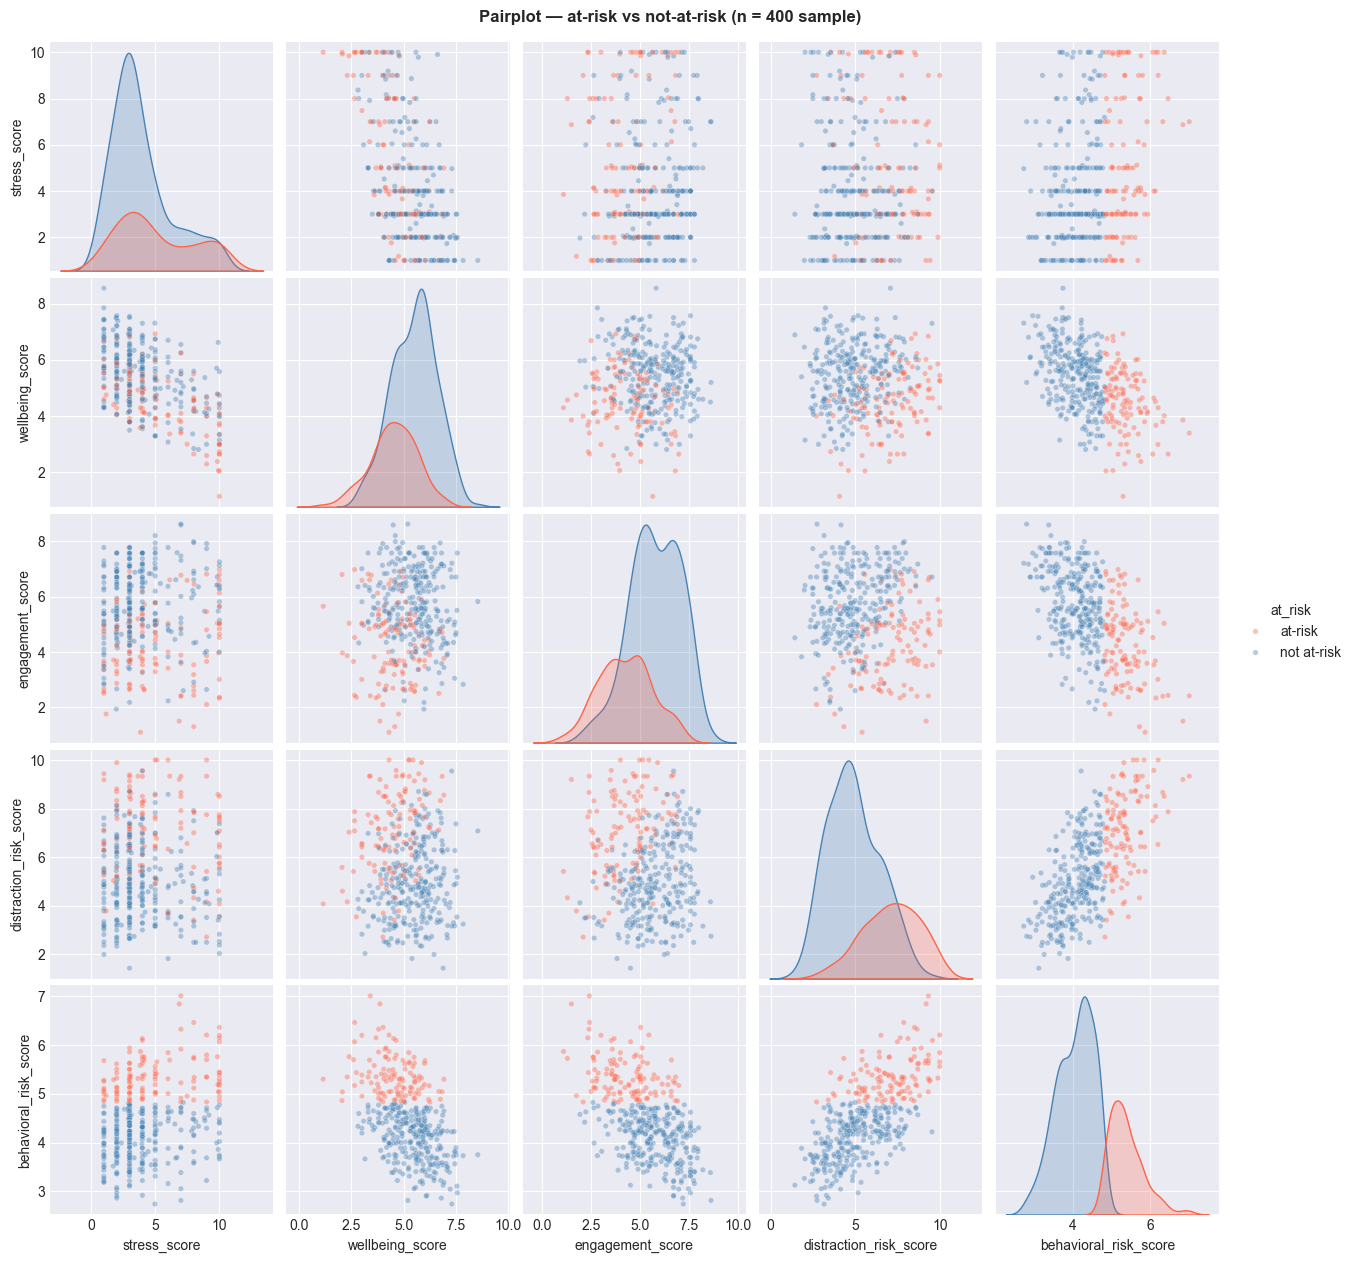

In [23]:
pair_cols = ['stress_score', 'wellbeing_score', 'engagement_score',
             'distraction_risk_score', 'behavioral_risk_score']

sample = (df[pair_cols + ['at_risk_label']].dropna()
            .sample(min(400, len(df)), random_state=42))
sample['at_risk'] = sample['at_risk_label'].map({0: 'not at-risk', 1: 'at-risk'})

pp = sns.pairplot(sample, vars=pair_cols, hue='at_risk',
                  palette={'not at-risk': 'steelblue', 'at-risk': 'tomato'},
                  plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
pp.fig.suptitle('Pairplot — at-risk vs not-at-risk (n = 400 sample)', y=1.01,
                fontsize=12, fontweight='bold')
plt.show()


##  Class imbalance (at-risk label)

=== At-risk label distribution ===
                 count   pct
at_risk_label               
Not at-risk (0)    619  69.4
At-risk (1)        273  30.6

Imbalance ratio: 2.27:1
✓  Acceptable balance


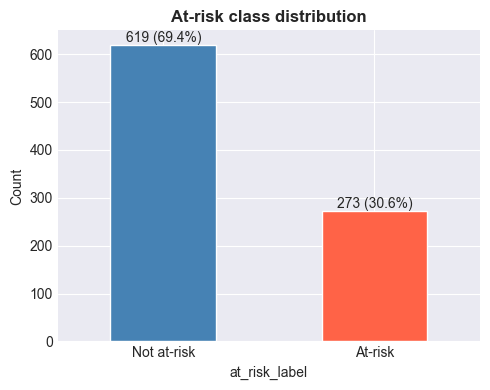

In [24]:
label_counts = df['at_risk_label'].value_counts()
label_pct    = df['at_risk_label'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'count': label_counts, 'pct': label_pct.round(1)})
summary.index = summary.index.map({0: 'Not at-risk (0)', 1: 'At-risk (1)'})
print('=== At-risk label distribution ===')
print(summary.to_string())

ratio = label_counts.max() / label_counts.min()
print(f'\nImbalance ratio: {ratio:.2f}:1')
if ratio > 3:
    print('⚠  Significant imbalance — consider SMOTE or class_weight="balanced"')
else:
    print('✓  Acceptable balance')

fig, ax = plt.subplots(figsize=(5, 4))
label_counts.rename({0: 'Not at-risk', 1: 'At-risk'}).plot.bar(
    ax=ax, color=['steelblue', 'tomato'], edgecolor='white', rot=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.set_title('At-risk class distribution', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


### Class imbalance
- At-risk threshold set at mean + 0.5 std = 4.83 (0–10 scale).
- ~30% of students flagged as at-risk — far less imbalanced than Dataset 1 (7.1%).
- Standard `class_weight='balanced'` is sufficient; SMOTE is optional here.